In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tensorflow import keras


In [ ]:
print('hola')

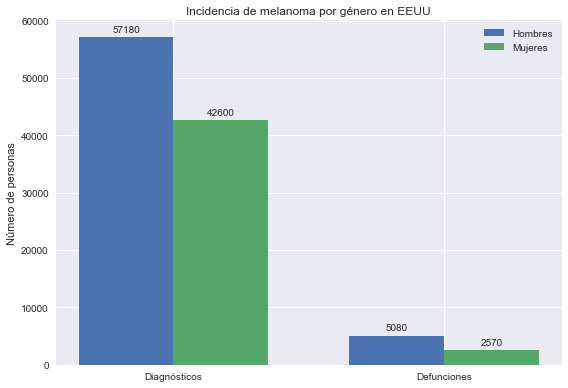

In [37]:
x = range(4)
men = [57180, 5080]
women = [42600, 2570]
labels = ['Diagnósticos', 'Defunciones']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

mpl.style.use('seaborn')
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, men, width, label='Hombres')
rects2 = ax.bar(x + width/2, women, width, label='Mujeres')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Número de personas')
ax.set_title('Incidencia de melanoma por género en EEUU')
ax.set_xticks(x, labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.savefig('plot', dpi=100)
plt.show()


In [9]:
import numpy as np


def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
   
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import numpy as np
    import itertools

    font = {'family' : 'normal',
            'weight' : 'normal',
            'size'   : 16}
    mpl.rc('font', **font)
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('Prueba diagnóstica')
    plt.xlabel('Diagnóstico esperado\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.savefig(title, dpi=100)
    plt.show()

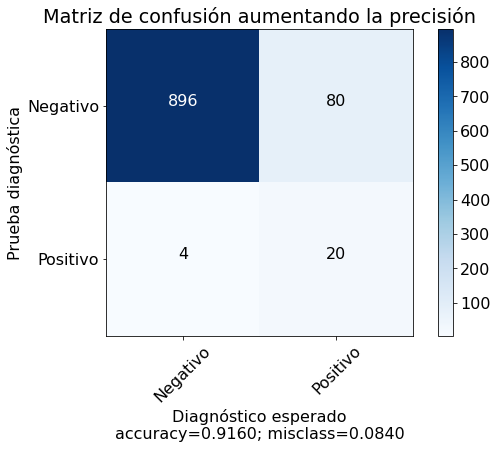

In [10]:
plot_confusion_matrix(cm = np.array([[ 896,  80],
                                    [  4,  20]]), 
                      normalize    = False,
                      target_names = ['Negativo', 'Positivo'],
                      title        = "Matriz de confusión aumentando la precisión")

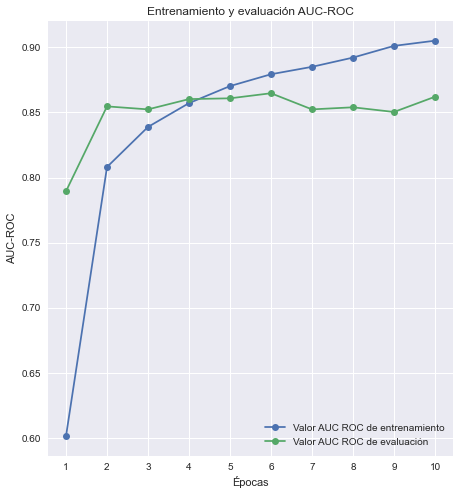

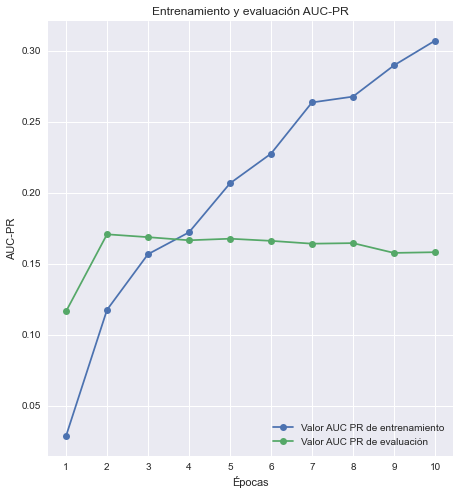

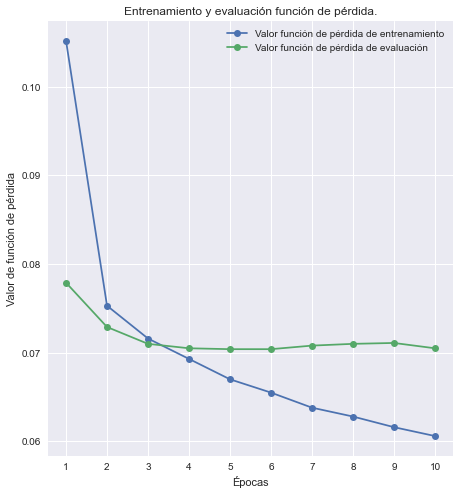

In [37]:

aucROC = [0.6013, 0.8081, 0.8389, 0.8572, 0.8703, 0.8794, 0.8851, 0.8922, 0.9012, 0.9052]
val_aucROC = [0.7895,0.8547,0.8524 ,0.8603 ,0.8609 ,0.8648 ,0.8524 ,0.8540 ,0.8504 ,0.8621]

aucPR = [0.0285 ,0.1174 ,0.1566 ,0.1720 ,0.2065 ,0.2274 ,0.2635 ,0.2676 ,0.2896 ,0.3070 ]
val_aucPR = [0.1163,0.1706,0.1686,0.1664,0.1675,0.1660,0.1640,0.1644,0.1575,0.1580]

loss = [0.1052 ,0.0753 ,0.0716 ,0.0693 ,0.0670 ,0.0655 ,0.0638 ,0.0628 ,0.0616 ,0.0606 ]
val_loss = [0.0779 ,0.0729 ,0.0710 ,0.0705 ,0.0704 ,0.0704 ,0.0708 ,0.0710 ,0.0711, 0.0705 ]

epochs_range = range(1,11)
mpl.style.use('seaborn')
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, aucROC, label='Valor AUC ROC de entrenamiento', marker='o')
plt.plot(epochs_range, val_aucROC, label='Valor AUC ROC de evaluación',marker='o')
plt.legend(loc='lower right')
plt.ylabel('AUC-ROC')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.title('Entrenamiento y evaluación AUC-ROC')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
plt.plot(epochs_range, aucPR, label='Valor AUC PR de entrenamiento',marker='o')
plt.plot(epochs_range, val_aucPR, label='Valor AUC PR de evaluación',marker='o')
plt.legend(loc='lower right')
plt.ylabel('AUC-PR')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.title('Entrenamiento y evaluación AUC-PR')

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Valor función de pérdida de entrenamiento',marker='o')
plt.plot(epochs_range, val_loss, label='Valor función de pérdida de evaluación',marker='o')
plt.legend(loc='upper right')
plt.title('Entrenamiento y evaluación función de pérdida.')
plt.ylabel('Valor de función de pérdida')
plt.xlabel('Épocas')
plt.xticks(epochs_range)
plt.show()

In [10]:
baseline2 = keras.models.load_model('models/baseline2ROCPR.h5')
baseline2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 2,049
Non-trainable params: 23,564,800
_____________________________________________